In [6]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.notebook import tqdm

# Para importar src/ desde el notebook
sys.path.append(str(Path.cwd().parent))
from src.config import DATA_RAW, OUTPUTS_DIR

# Estética
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 110

In [19]:
def load_ims_experiment(exp_path: Path, n_channels: int) -> dict[str, pd.DataFrame]:
    """
    Lee todos los archivos .txt de un experimento IMS.
    
    Devuelve un dict: {"bearing_1": DataFrame, "bearing_2": DataFrame, ...}
    Cada DataFrame tiene shape (n_snapshots, n_channels) con la señal cruda
    del último snapshot leído. Aquí cargamos snapshot a snapshot para EDA.
    
    Para el EDA usamos solo el primer snapshot y el último para comparar.
    Para feature engineering (Paso 2) procesaremos todos.
    """
    files = sorted([f for f in exp_path.iterdir() if f.is_file()])
    
    if n_channels == 8:
        col_names = [f"b{b}_ch{c}" for b in range(1, 5) for c in range(1, 3)]
    else:  # 4 columnas
        col_names = [f"b{b}_ch1" for b in range(1, 5)]
    
    bearing_data = {name: [] for name in [f"bearing_{i}" for i in range(1, 5)]}
    
    for f in tqdm(files, desc=f"Cargando {exp_path.name}"):
        df = pd.read_csv(f, sep="\t", header=None, names=col_names)
        
        for b_idx in range(1, 5):
            b_key = f"bearing_{b_idx}"
            if n_channels == 8:
                cols = [f"b{b_idx}_ch1", f"b{b_idx}_ch2"]
            else:
                cols = [f"b{b_idx}_ch1"]
            bearing_data[b_key].append(df[cols].values)
    
    # Resultado: por cada rodamiento, lista de arrays (uno por snapshot)
    return bearing_data, col_names, files

In [20]:
experiments_meta = {
    "exp1": {"path": DATA_RAW / "1st_test", "n_channels": 8},
    "exp2": {"path": DATA_RAW / "2nd_test", "n_channels": 4},
    "exp3": {"path": DATA_RAW / "3rd_test", "n_channels": 4},
}

experiments = {}
for exp_name, meta in experiments_meta.items():
    print(f"\n{'='*50}")
    print(f"Cargando {exp_name} desde {meta['path']}")
    data, cols, files = load_ims_experiment(meta["path"], meta["n_channels"])
    experiments[exp_name] = {
        "data"    : data,
        "cols"    : cols,
        "files"   : files,
        "n_files" : len(files),
    }
    print(f"  → {len(files)} snapshots encontrados")
    print(f"  → Columnas: {cols}")


Cargando exp1 desde /home/adrian-pc/Documentos/ml-personales/deeplearning/rul_bearing/data/raw/1st_test


Cargando 1st_test:   0%|          | 0/2156 [00:00<?, ?it/s]

  → 2156 snapshots encontrados
  → Columnas: ['b1_ch1', 'b1_ch2', 'b2_ch1', 'b2_ch2', 'b3_ch1', 'b3_ch2', 'b4_ch1', 'b4_ch2']

Cargando exp2 desde /home/adrian-pc/Documentos/ml-personales/deeplearning/rul_bearing/data/raw/2nd_test


Cargando 2nd_test:   0%|          | 0/984 [00:00<?, ?it/s]

  → 984 snapshots encontrados
  → Columnas: ['b1_ch1', 'b2_ch1', 'b3_ch1', 'b4_ch1']

Cargando exp3 desde /home/adrian-pc/Documentos/ml-personales/deeplearning/rul_bearing/data/raw/3rd_test


Cargando 3rd_test:   0%|          | 0/6324 [00:00<?, ?it/s]

  → 6324 snapshots encontrados
  → Columnas: ['b1_ch1', 'b2_ch1', 'b3_ch1', 'b4_ch1']


In [22]:
print("RESUMEN DEL DATASET IMS")
print("="*50)
for exp_name, exp in experiments.items():
    n = exp["n_files"]
    # Cada snapshot = 10 minutos → duración total del experimento
    duracion_horas = n * 10 / 60
    print(f"\n{exp_name}:")
    print(f"  Snapshots : {n}")
    print(f"  Duración  : {duracion_horas:.1f} horas ({duracion_horas/24:.1f} días)")
    print(f"  Canales   : {len(exp['cols'])}")
    
    # Mostrar el primer archivo para ver la forma del dato crudo
    first_snapshot = exp["data"]["bearing_1"][0]
    print(f"  Shape por snapshot (filas × canales): {first_snapshot.shape}")


RESUMEN DEL DATASET IMS

exp1:
  Snapshots : 2156
  Duración  : 359.3 horas (15.0 días)
  Canales   : 8
  Shape por snapshot (filas × canales): (20480, 2)

exp2:
  Snapshots : 984
  Duración  : 164.0 horas (6.8 días)
  Canales   : 4
  Shape por snapshot (filas × canales): (20480, 1)

exp3:
  Snapshots : 6324
  Duración  : 1054.0 horas (43.9 días)
  Canales   : 4
  Shape por snapshot (filas × canales): (20480, 1)


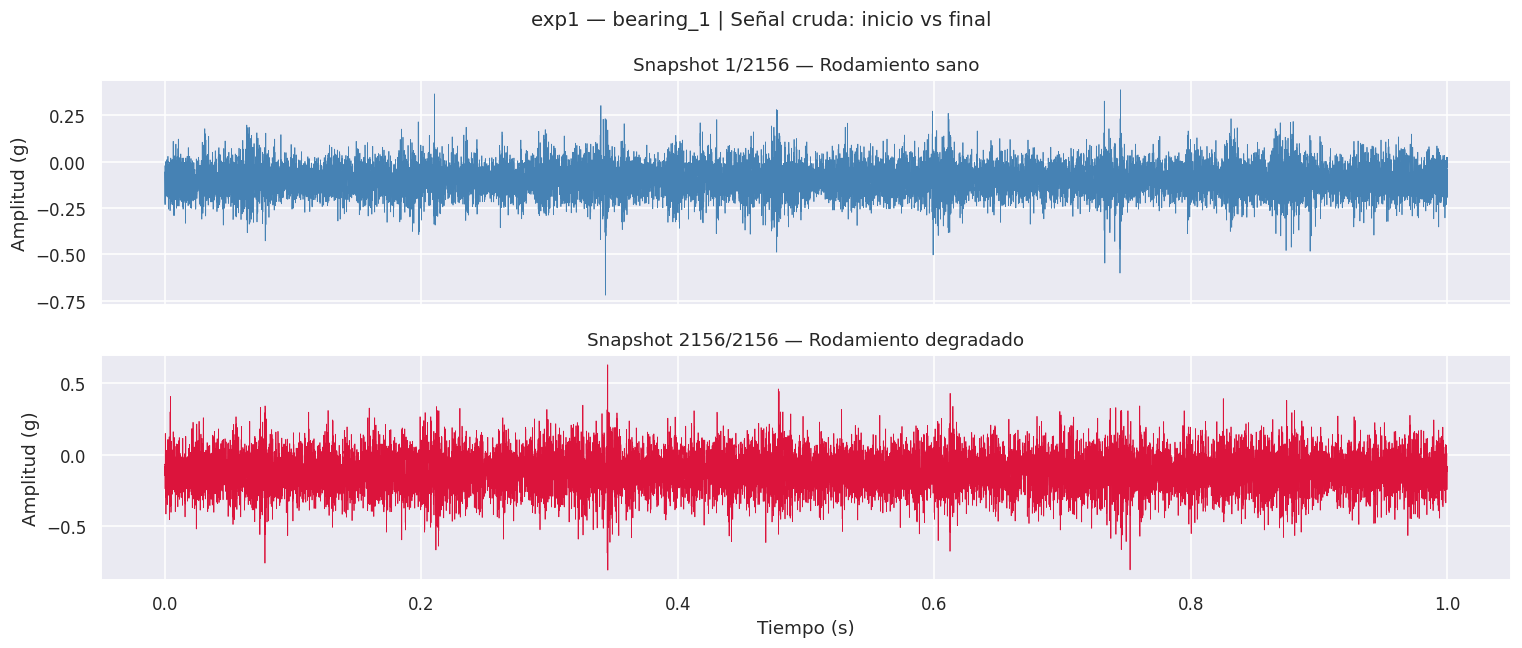

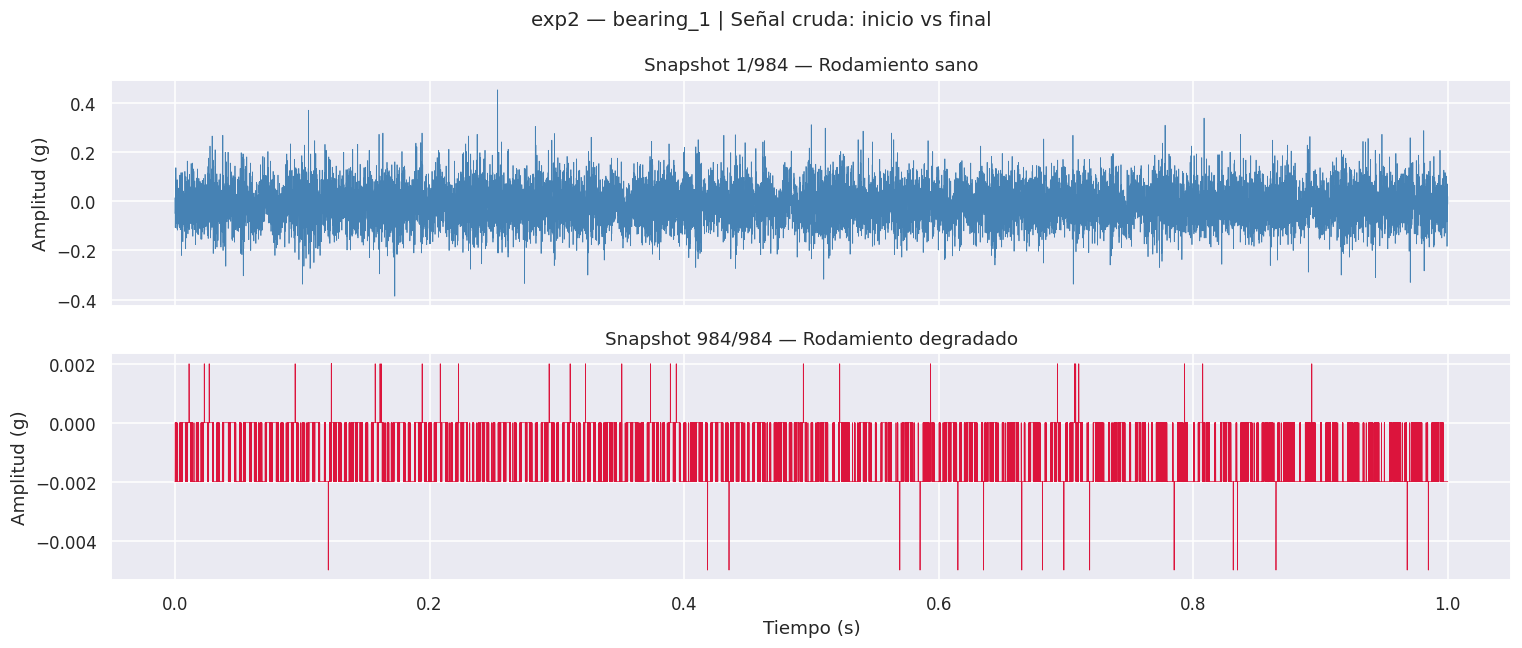

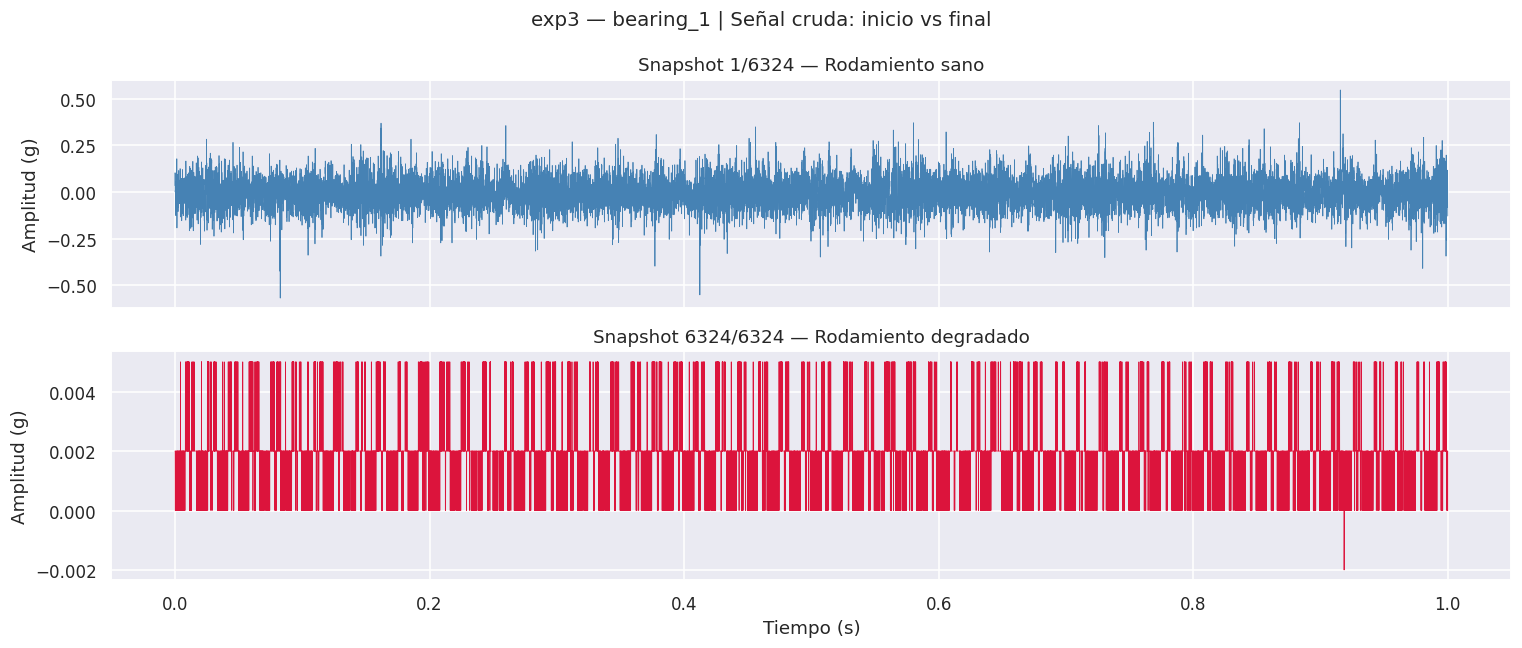

In [23]:
def plot_raw_signal_comparison(exp_data: dict, exp_name: str, bearing: str = "bearing_1"):
    snapshots = exp_data["data"][bearing]
    n = len(snapshots)
    
    # Tomamos snapshot inicial (sano) y final (degradado/fallido)
    snap_early = snapshots[0]
    snap_late  = snapshots[-1]
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f"{exp_name} — {bearing} | Señal cruda: inicio vs final", fontsize=13)
    
    t = np.arange(snap_early.shape[0]) / 20_480  # eje temporal en segundos
    
    axes[0].plot(t, snap_early[:, 0], color="steelblue", linewidth=0.5)
    axes[0].set_title(f"Snapshot 1/{n} — Rodamiento sano")
    axes[0].set_ylabel("Amplitud (g)")
    
    axes[1].plot(t, snap_late[:, 0], color="crimson", linewidth=0.5)
    axes[1].set_title(f"Snapshot {n}/{n} — Rodamiento degradado")
    axes[1].set_ylabel("Amplitud (g)")
    axes[1].set_xlabel("Tiempo (s)")
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / f"eda_{exp_name}_{bearing}_raw_comparison.png", dpi=120)
    plt.show()

# Ejecutar para cada experimento
for exp_name, exp in experiments.items():
    plot_raw_signal_comparison(exp, exp_name, bearing="bearing_1")

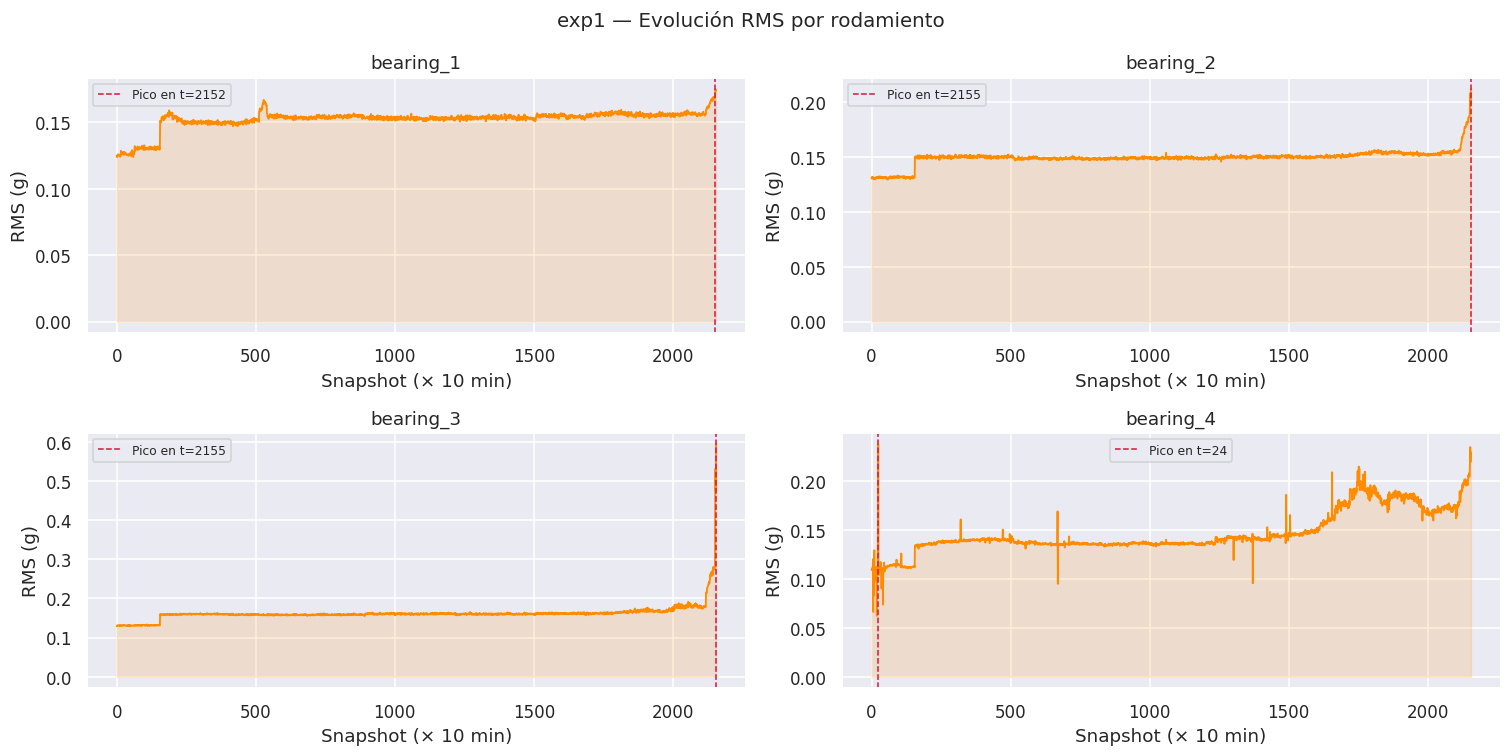

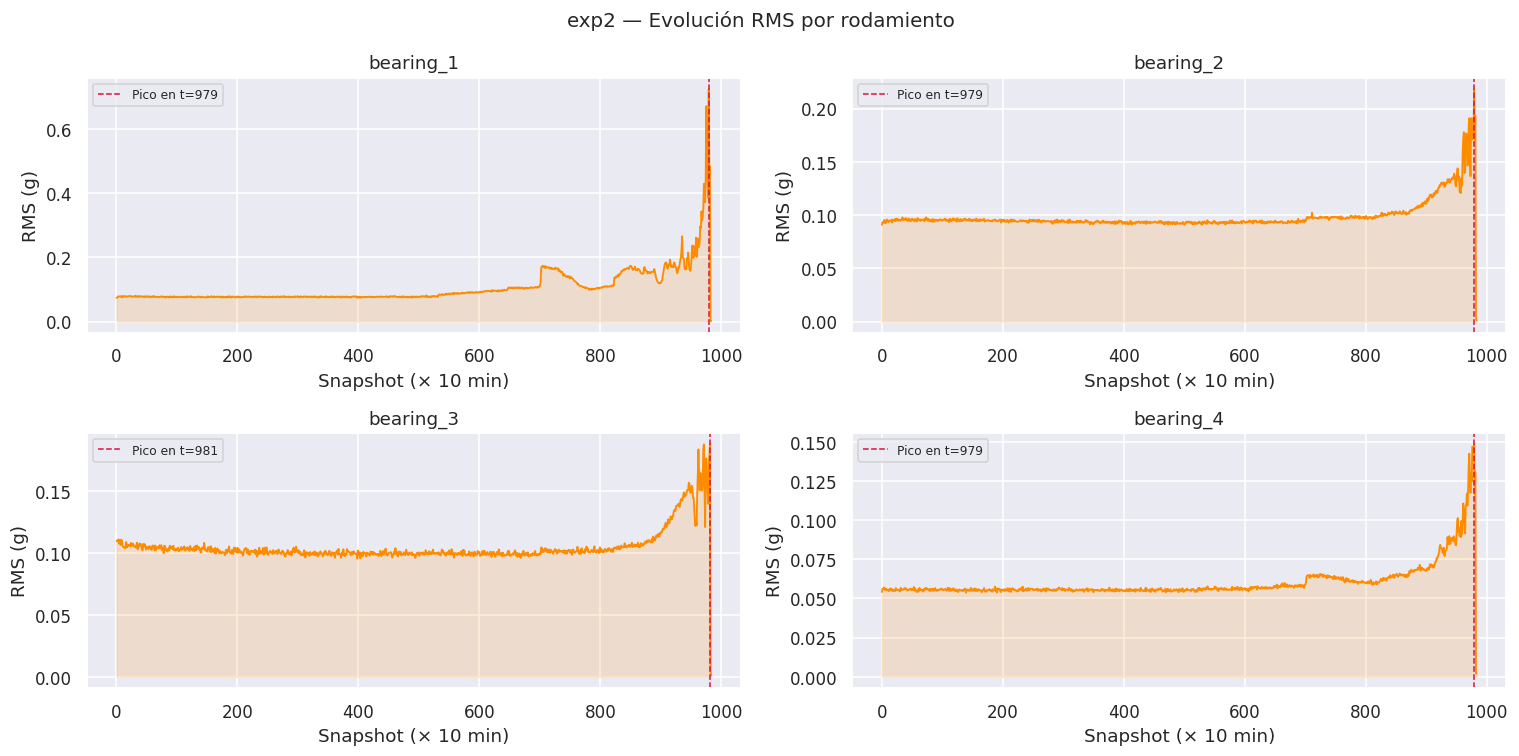

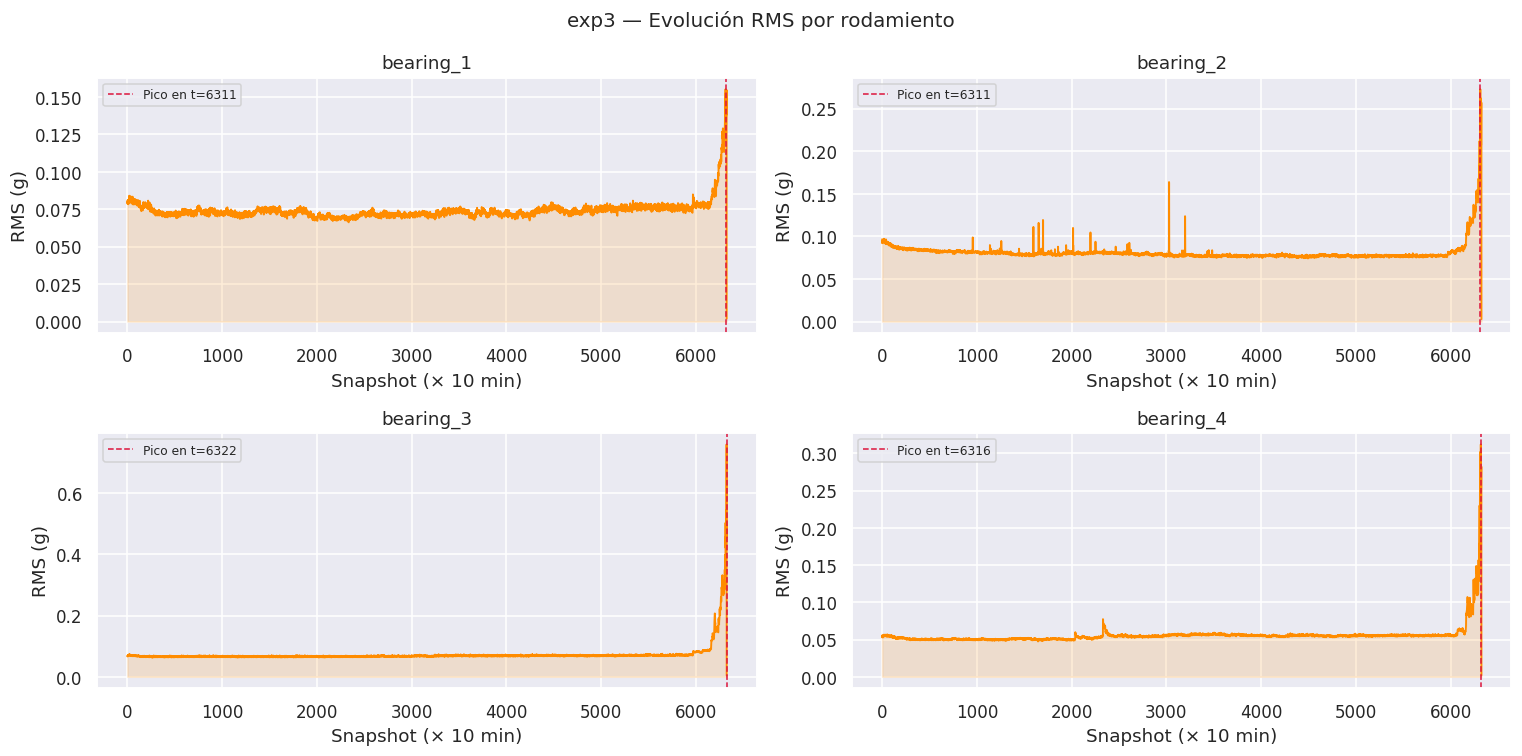

In [24]:
def compute_rms_evolution(snapshots: list) -> np.ndarray:
    """Calcula el RMS del canal 1 para cada snapshot."""
    return np.array([np.sqrt(np.mean(s[:, 0] ** 2)) for s in snapshots])


def plot_rms_all_bearings(exp_data: dict, exp_name: str):
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=False)
    axes = axes.flatten()
    fig.suptitle(f"{exp_name} — Evolución RMS por rodamiento", fontsize=13)
    
    for i, (bearing, snapshots) in enumerate(exp_data["data"].items()):
        rms = compute_rms_evolution(snapshots)
        x   = np.arange(len(rms))
        
        axes[i].plot(x, rms, linewidth=1.2, color="darkorange")
        axes[i].fill_between(x, rms, alpha=0.15, color="darkorange")
        axes[i].set_title(bearing)
        axes[i].set_xlabel("Snapshot (× 10 min)")
        axes[i].set_ylabel("RMS (g)")
        
        # Marcar el máximo (probable zona de fallo)
        peak_idx = np.argmax(rms)
        axes[i].axvline(peak_idx, color="crimson", linestyle="--", linewidth=1,
                        label=f"Pico en t={peak_idx}")
        axes[i].legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / f"eda_{exp_name}_rms_evolution.png", dpi=120)
    plt.show()

for exp_name, exp in experiments.items():
    plot_rms_all_bearings(exp, exp_name)

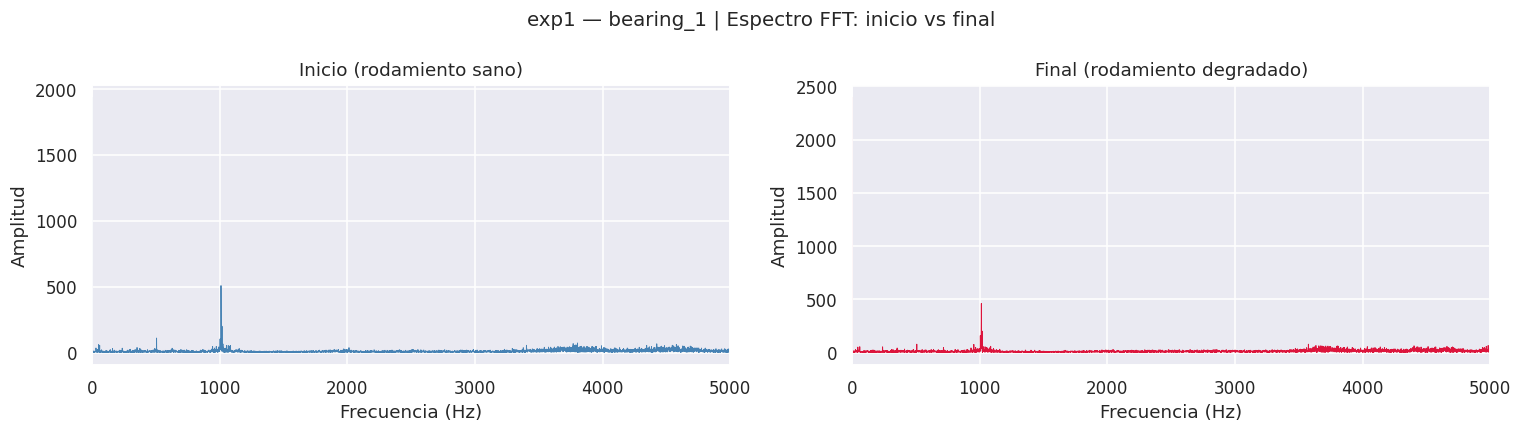

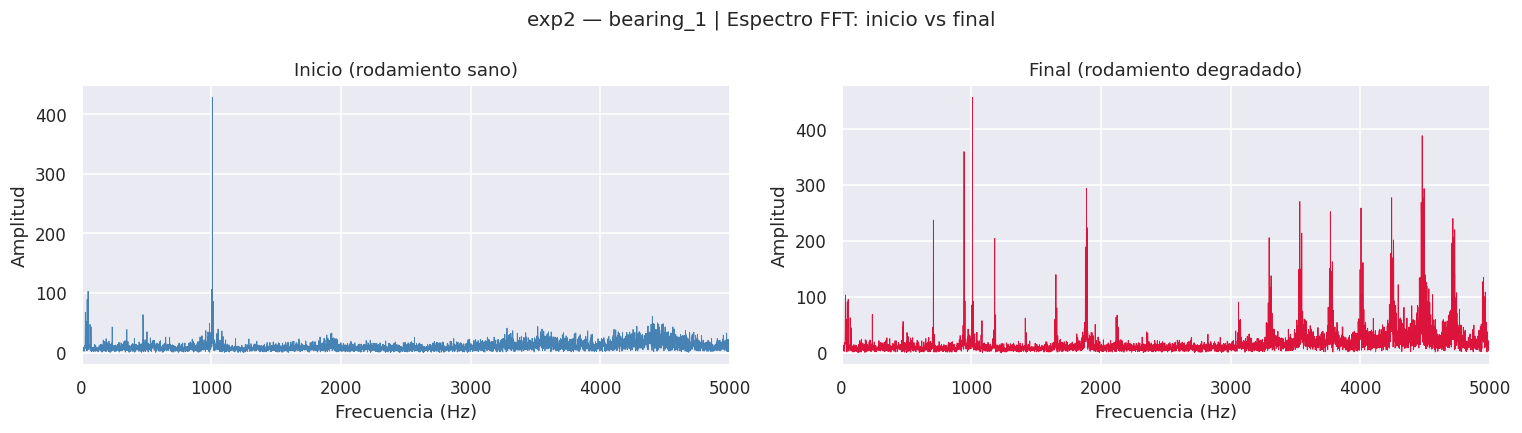

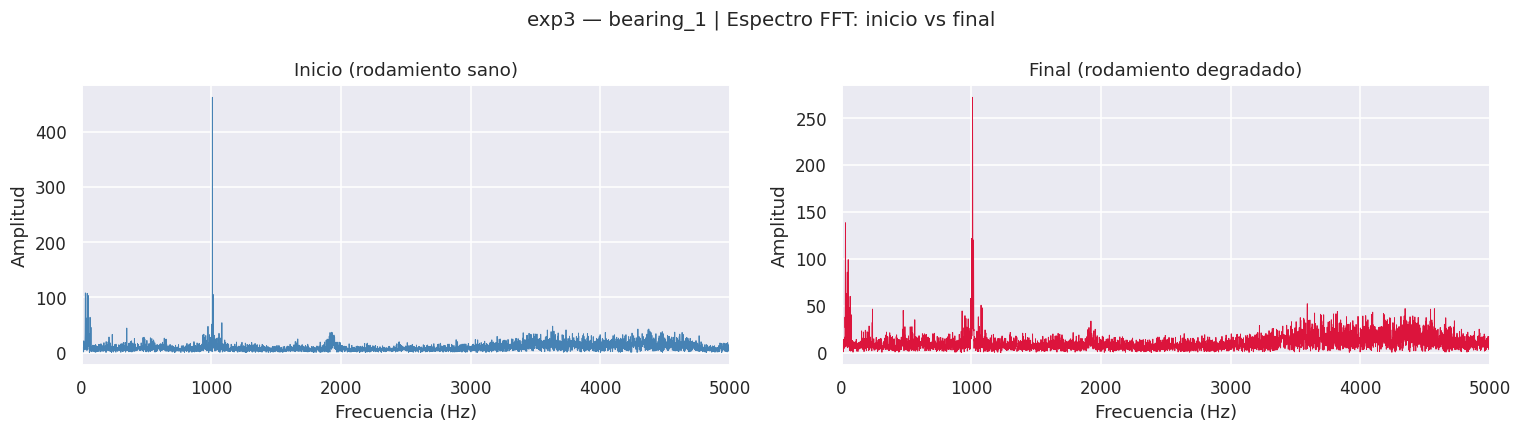

In [28]:
def plot_fft_comparison(exp_data: dict, exp_name: str, bearing: str = "bearing_1"):
    snapshots = exp_data["data"][bearing]
    fs        = 20_480  # Hz
    n_samples = snapshots[0].shape[0]
    freqs     = np.fft.rfftfreq(n_samples, d=1/fs)
    
    snap_early = snapshots[int(len(snapshots) * 0.05)]   # 5% del experimento
    snap_late  = snapshots[int(len(snapshots) * 0.90)]   # 95% del experimento
    
    fft_early = np.abs(np.fft.rfft(snap_early[:, 0]))
    fft_late  = np.abs(np.fft.rfft(snap_late[:, 0]))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{exp_name} — {bearing} | Espectro FFT: inicio vs final", fontsize=13)
    
    for ax, fft_vals, label, color in zip(
        axes,
        [fft_early, fft_late],
        ["Inicio (rodamiento sano)", "Final (rodamiento degradado)"],
        ["steelblue", "crimson"]
    ):
        ax.plot(freqs, fft_vals, linewidth=0.6, color=color)
        ax.set_xlim(0, 5000)   # Zona de interés hasta 5 kHz
        ax.set_title(label)
        ax.set_xlabel("Frecuencia (Hz)")
        ax.set_ylabel("Amplitud")
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / f"eda_{exp_name}_{bearing}_fft.png", dpi=120)
    plt.show()

for exp_name, exp in experiments.items():
    plot_fft_comparison(exp, exp_name)

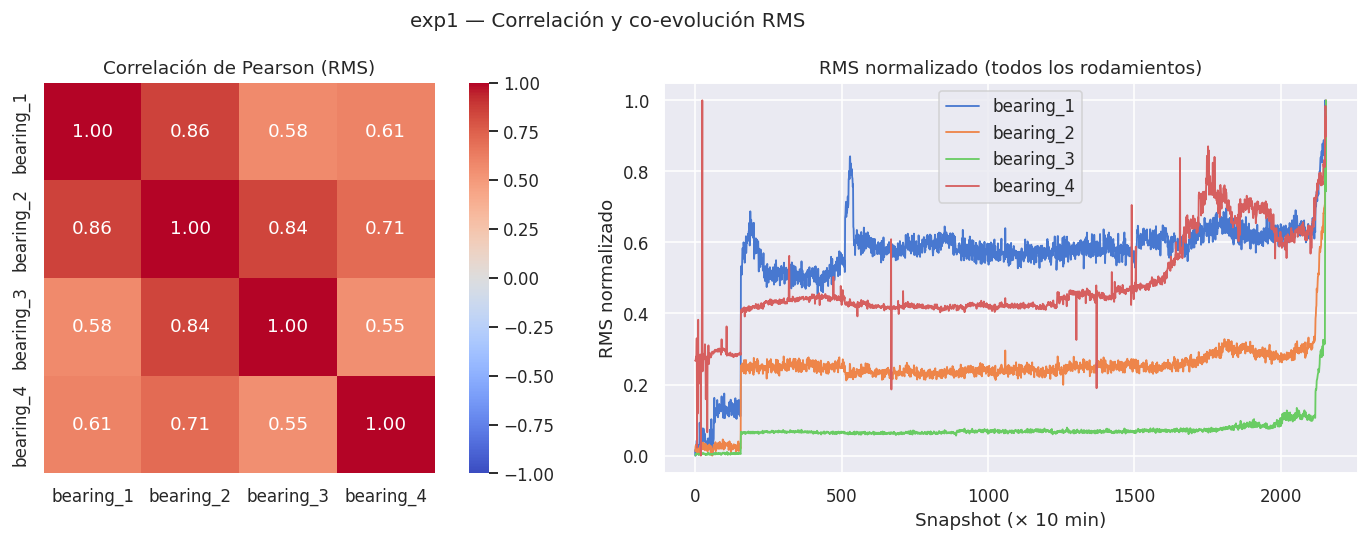

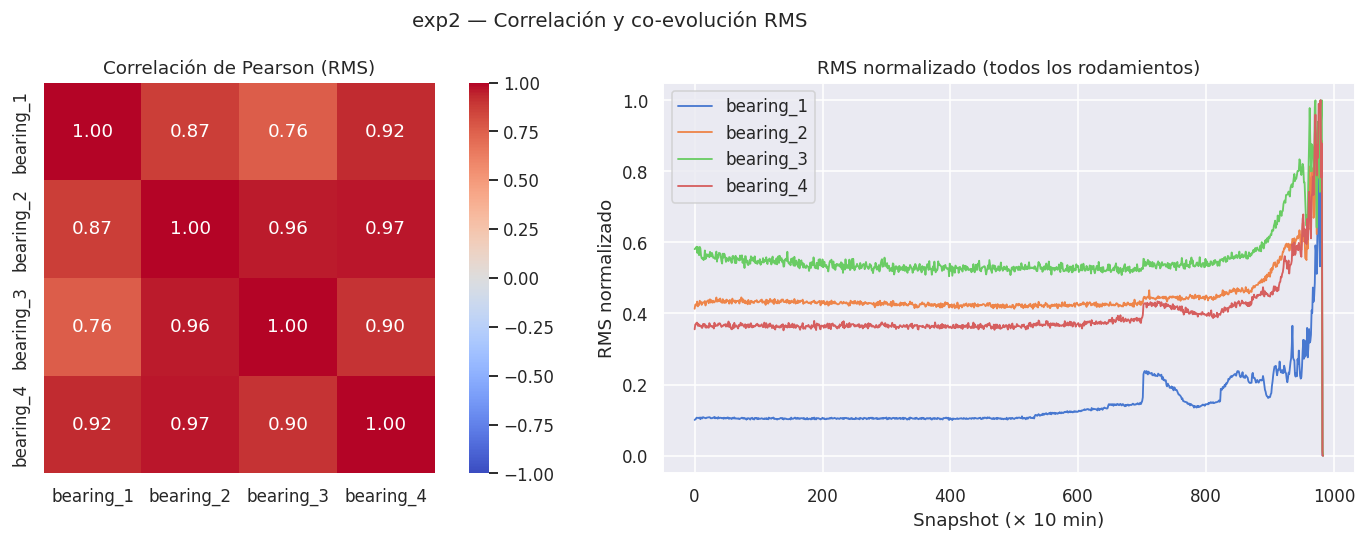

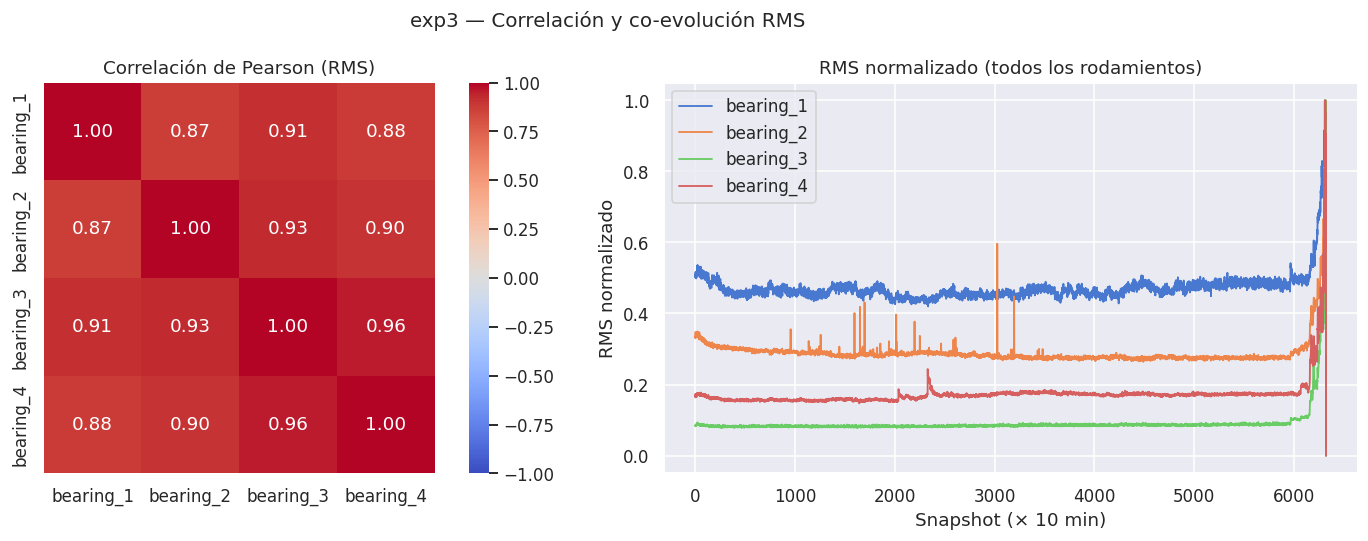

In [26]:
def plot_rms_correlation(exp_data: dict, exp_name: str):
    rms_df = pd.DataFrame({
        bearing: compute_rms_evolution(snapshots)
        for bearing, snapshots in exp_data["data"].items()
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{exp_name} — Correlación y co-evolución RMS", fontsize=13)
    
    # Heatmap de correlación
    corr = rms_df.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                ax=axes[0], vmin=-1, vmax=1, square=True)
    axes[0].set_title("Correlación de Pearson (RMS)")
    
    # Evolución conjunta normalizada
    rms_norm = (rms_df - rms_df.min()) / (rms_df.max() - rms_df.min())
    for col in rms_norm.columns:
        axes[1].plot(rms_norm[col], linewidth=1.2, label=col)
    axes[1].set_title("RMS normalizado (todos los rodamientos)")
    axes[1].set_xlabel("Snapshot (× 10 min)")
    axes[1].set_ylabel("RMS normalizado")
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / f"eda_{exp_name}_correlation.png", dpi=120)
    plt.show()

for exp_name, exp in experiments.items():
    plot_rms_correlation(exp, exp_name)